# Student Academic Performance Prediction Using Supervised Machine Learning

### AI Internship - Week 2

This project applies supervised machine learning techniques to a student academic dataset. Regression and classification models are trained using Scikit-learn to predict student performance and evaluate model performance using appropriate metrics.

## Objective

The objectives of this project are:

- To understand supervised machine learning.
- To prepare a dataset for machine learning.
- To split data into training and testing sets.
- To implement regression and classification algorithms.
- To train models and generate predictions.
- To evaluate models using appropriate performance metrics.
- To compare the performance of different machine learning models.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler

In [3]:
data = {
    "Student_ID": [
        "ST001", "ST002", "ST003", "ST004", "ST005",
        "ST006", "ST007", "ST008", "ST009", "ST010",
        "ST011", "ST012", "ST013", "ST014", "ST015",
        "ST016", "ST017", "ST018", "ST019", "ST020",
        "ST021", "ST022", "ST023", "ST024", "ST025",
        "ST026", "ST027", "ST028", "ST029", "ST030"
    ],

    "Age": [
        20, 21, 19, 22, 20,
        21, 19, 23, 20, 22,
        21, 20, 19, 24, 21,
        20, 22, 19, 23, 20,
        21, 22, 20, 19, 24,
        21, 20, 23, 22, 19
    ],

    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male"
    ],

    "Program": [
        "Creative Arts", "Liberal Arts", "Science", "Science", "Creative Arts",
        "Liberal Arts", "Science", "Creative Arts", "Science", "Liberal Arts",
        "Creative Arts", "Science", "Liberal Arts", "Science", "Creative Arts",
        "Science", "Liberal Arts", "Creative Arts", "Science", "Liberal Arts",
        "Science", "Creative Arts", "Liberal Arts", "Science", "Creative Arts",
        "Liberal Arts", "Science", "Creative Arts", "Science", "Liberal Arts"
    ],

    "Year": [
        2, 3, 1, 4, 2,
        3, 1, 4, 2, 3,
        2, 1, 3, 4, 2,
        1, 3, 4, 2, 3,
        1, 2, 3, 1, 4,
        2, 3, 1, 4, 2
    ],

    "Attendance": [
        87, 92, 78, 65, 95,
        88, 76, 90, 82, 85,
        91, 72, 80, 68, 94,
        77, 89, 63, 86, 93,
        74, 96, 81, 79, 67,
        90, 84, 71, 88, 75
    ],

    "Study_Hours": [
        12, 15, 8, 6, 14,
        11, 7, 13, 10, 12,
        14, 6, 9, 5, 15,
        8, 11, 13, 10, 14,
        7, 16, 9, 8, 6,
        12, 10, 7, 13, 8
    ],

    "Exam_Score": [
        82, 91, 74, 61, 88,
        84, 70, 87, 79, 83,
        90, 68, 76, 64, 92,
        73, 85, 89, 78, 86,
        69, 94, 81, 75, 66,
        88, 80, 72, 90, 71
    ]
}

df = pd.DataFrame(data)

df.head()

,Student_ID,Age,Gender,Program,Year,Attendance,Study_Hours,Exam_Score
0,ST001,20,Male,Creative Arts,2,87,12,82
1,ST002,21,Female,Liberal Arts,3,92,15,91
2,ST003,19,Male,Science,1,78,8,74
3,ST004,22,Female,Science,4,65,6,61
4,ST005,20,Male,Creative Arts,2,95,14,88


## 1. Dataset Inspection

The dataset is inspected to understand its structure, dimensions, data types, and numerical characteristics before applying machine learning algorithms.

In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (30, 8)

Column names:
Index(['Student_ID', 'Age', 'Gender', 'Program', 'Year', 'Attendance',
       'Study_Hours', 'Exam_Score'],
      dtype='object')

Data types:
Student_ID     object
Age             int64
Gender         object
Program        object
Year            int64
Attendance      int64
Study_Hours     int64
Exam_Score      int64
dtype: object

Missing values:
Student_ID     0
Age            0
Gender         0
Program        0
Year           0
Attendance     0
Study_Hours    0
Exam_Score     0
dtype: int64


In [5]:
df.describe()

,Age,Year,Attendance,Study_Hours,Exam_Score
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,20.900000,2.433333,81.866667,10.300000,79.533333
std,1.516575,1.072648,9.485864,3.163913,9.205446
min,19.000000,1.000000,63.000000,5.000000,61.000000
25%,20.000000,2.000000,75.250000,8.000000,72.250000
50%,21.000000,2.000000,83.000000,10.000000,80.500000
75%,22.000000,3.000000,89.750000,13.000000,87.750000
max,24.000000,4.000000,96.000000,16.000000,94.000000


In [6]:
df.head(10)

,Student_ID,Age,Gender,Program,Year,Attendance,Study_Hours,Exam_Score
0,ST001,20,Male,Creative Arts,2,87,12,82
1,ST002,21,Female,Liberal Arts,3,92,15,91
2,ST003,19,Male,Science,1,78,8,74
3,ST004,22,Female,Science,4,65,6,61
4,ST005,20,Male,Creative Arts,2,95,14,88
5,ST006,21,Female,Liberal Arts,3,88,11,84
6,ST007,19,Male,Science,1,76,7,70
7,ST008,23,Female,Creative Arts,4,90,13,87
8,ST009,20,Male,Science,2,82,10,79
9,ST010,22,Female,Liberal Arts,3,85,12,83


Before training machine learning models, the dataset must be inspected to identify its structure, variable types, and potential missing values. This helps determine which preprocessing steps are required before model training.

## 2. Feature Selection

The Student_ID column is an identifier and does not provide meaningful information for predicting academic performance. Therefore, it is excluded from the feature set.

Exam_Score is selected as the target variable because the regression models will be used to predict a student's numerical exam score.

In [7]:
X = df.drop (columns = ["Student_ID", "Exam_Score"])
y = df["Exam_Score"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Age', 'Gender', 'Program', 'Year', 'Attendance', 'Study_Hours'], dtype='object')

Target:
Exam_Score


## 3. Categorical Encoding

The Gender and Program variables are categorical. One-hot encoding is used to convert these categories into numerical features that can be processed by machine-learning algorithms.

One-hot encoding is appropriate because the categories do not have a natural numerical order.

In [8]:
X = pd.get_dummies(
    X,
    columns=["Gender", "Program"],
    drop_first=True
)

X.head()

,Age,Year,Attendance,Study_Hours,Gender_Male,Program_Liberal Arts,Program_Science
0,20,2,87,12,True,False,False
1,21,3,92,15,False,True,False
2,19,1,78,8,True,False,True
3,22,4,65,6,False,False,True
4,20,2,95,14,True,False,False


In [9]:
print(X.columns)

Index(['Age', 'Year', 'Attendance', 'Study_Hours', 'Gender_Male',
       'Program_Liberal Arts', 'Program_Science'],
      dtype='object')


## 4. Train-Test Split

The dataset is divided into training and testing sets. The training data is used to learn patterns from the observations, while the testing data is used to evaluate how well the trained model performs on previously unseen observations.

An 80:20 split is used, with 80% of the observations used for training and 20% for testing.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (24, 7)
Testing features: (6, 7)
Training target: (24,)
Testing target: (6,)


## 5. Linear Regression

Linear Regression is used as the first regression model because the target variable, Exam_Score, is numerical. The model attempts to learn a linear relationship between the input features and exam score.

In [11]:
# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred = linear_model.predict(X_test)

print("Predicted Exam Scores:")
print(y_pred)

Predicted Exam Scores:
[67.25879799 71.92887808 73.08218843 69.42915474 77.42336445 83.74084065]


## 6. Linear Regression Evaluation

The Linear Regression model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

MAE and RMSE measure prediction error, where lower values generally indicate smaller prediction errors. R² measures the proportion of variation in the target variable explained by the model.

In [12]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Performance
-----------------------------
MAE : 4.936409493894016
RMSE: 8.300169762084936
R²  : -0.9181295056917615


## 7. Decision Tree Regression

A Decision Tree Regressor is used as a second regression model. Unlike Linear Regression, a decision tree can capture non-linear relationships between the input features and the target variable.

The model repeatedly divides the data based on feature values and uses these divisions to make numerical predictions.

In [13]:
# Create the Decision Tree model
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=3
)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
tree_pred = tree_model.predict(X_test)

print("Decision Tree Predictions:")
print(tree_pred)

Decision Tree Predictions:
[61.  69.5 75.  69.5 81.  78. ]


## 8. Decision Tree Regression Evaluation

The Decision Tree Regressor is evaluated using the same metrics as Linear Regression: MAE, RMSE, and R² Score. Using the same evaluation metrics allows the performance of the two models to be compared consistently.

In [14]:
tree_mae = mean_absolute_error(y_test, tree_pred)

tree_mse = mean_squared_error(y_test, tree_pred)

tree_rmse = np.sqrt(tree_mse)

tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Regression Performance")
print("------------------------------------")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree Regression Performance
------------------------------------
MAE : 6.833333333333333
RMSE: 9.508767883730608
R²  : -1.5174013921113687


## 9. Regression Model Comparison

The performance of Linear Regression and Decision Tree Regression is compared using MAE, RMSE, and R² Score.

MAE and RMSE represent prediction errors, where lower values indicate smaller errors. R² measures the proportion of variation in exam scores explained by the model.

In [15]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression"
    ],
    "MAE": [
        mae,
        tree_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse
    ],
    "R2 Score": [
        r2,
        tree_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.936409,8.300170,-0.918130
1,Decision Tree Regression,6.833333,9.508768,-1.517401


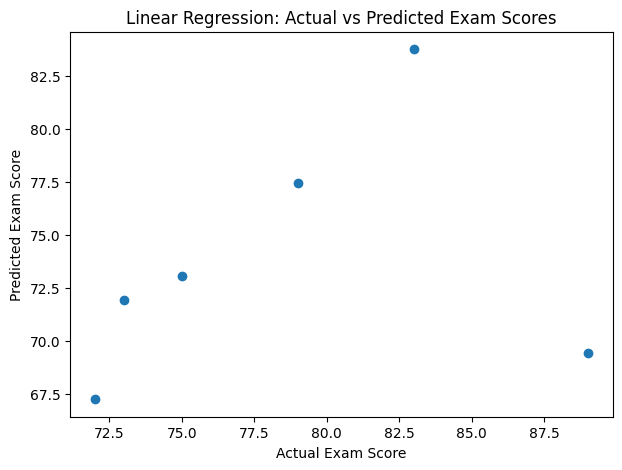

In [16]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted Exam Scores")

plt.show()

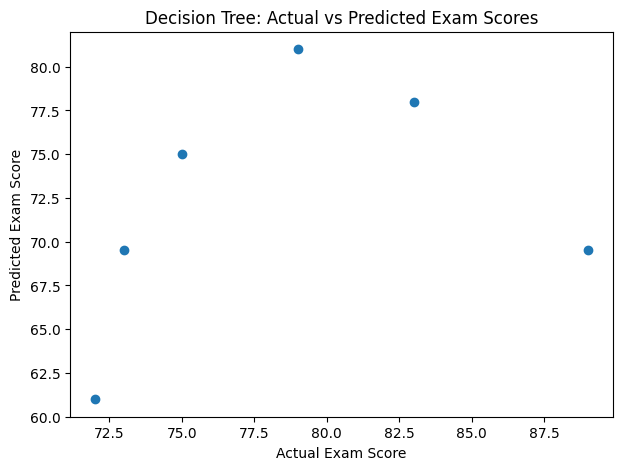

In [17]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, tree_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Decision Tree: Actual vs Predicted Exam Scores")

plt.show()

## 10. Creating a Classification Target

To demonstrate classification algorithms, the numerical Exam_Score variable is converted into a binary performance category.

Students with an Exam_Score of 75 or above are classified as "Pass", while students with a score below 75 are classified as "Not Pass".

This creates a binary classification problem suitable for Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors.

In [18]:
df["Performance"] = np.where(
    df["Exam_Score"] >= 75,
    "Pass",
    "Not Pass"
)

df[["Exam_Score", "Performance"]].head(10)

,Exam_Score,Performance
0,82,Pass
1,91,Pass
2,74,Not Pass
3,61,Not Pass
4,88,Pass
5,84,Pass
6,70,Not Pass
7,87,Pass
8,79,Pass
9,83,Pass


## 11. Preparing Data for Classification

The same student characteristics used in the regression task are used as input features for classification.

The Performance column is used as the target variable. Student_ID and Exam_Score are excluded from the feature set because Student_ID is an identifier and Exam_Score was used to create the target category.

In [19]:
X_class = df.drop(
    columns=["Student_ID", "Exam_Score", "Performance"]
)

y_class = df["Performance"]

In [20]:
X_class = pd.get_dummies(
    X_class,
    columns=["Gender", "Program"],
    drop_first=True
)

X_class.head()

,Age,Year,Attendance,Study_Hours,Gender_Male,Program_Liberal Arts,Program_Science
0,20,2,87,12,True,False,False
1,21,3,92,15,False,True,False
2,19,1,78,8,True,False,True
3,22,4,65,6,False,False,True
4,20,2,95,14,True,False,False


## 12. Train-Test Split for Classification

The classification dataset is divided into training and testing sets using an 80:20 split.

The `stratify` parameter is used so that the proportion of Pass and Not Pass observations is maintained as closely as possible between the training and testing sets.

In [21]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training features:", X_train_c.shape)
print("Testing features:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts())

print("\nTesting target distribution:")
print(y_test_c.value_counts())

Training features: (24, 7)
Testing features: (6, 7)

Training target distribution:
Performance
Pass        16
Not Pass     8
Name: count, dtype: int64

Testing target distribution:
Performance
Pass        4
Not Pass    2
Name: count, dtype: int64


## 13. Logistic Regression

Logistic Regression is used as the first classification model because the target variable contains two categories: Pass and Not Pass.

The model estimates the probability of an observation belonging to a particular class and assigns the corresponding class label.

In [22]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_c, y_train_c)

logistic_pred = logistic_model.predict(X_test_c)

print("Logistic Regression Predictions:")
print(logistic_pred)

Logistic Regression Predictions:
['Not Pass' 'Pass' 'Pass' 'Pass' 'Not Pass' 'Pass']


## 14. Logistic Regression Evaluation

The classification model is evaluated using Accuracy, Precision, Recall, and F1-score.

Accuracy measures the proportion of correct predictions. Precision measures how many predicted positive cases were actually positive. Recall measures how many actual positive cases were correctly identified. F1-score provides a combined measure of precision and recall.

In [23]:
logistic_accuracy = accuracy_score(
    y_test_c,
    logistic_pred
)

logistic_precision = precision_score(
    y_test_c,
    logistic_pred,
    pos_label="Pass",
    zero_division=0
)

logistic_recall = recall_score(
    y_test_c,
    logistic_pred,
    pos_label="Pass",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test_c,
    logistic_pred,
    pos_label="Pass",
    zero_division=0
)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression Performance
--------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## 15. Confusion Matrix

A confusion matrix is used to examine the classification results by showing the number of correct and incorrect predictions for each class.

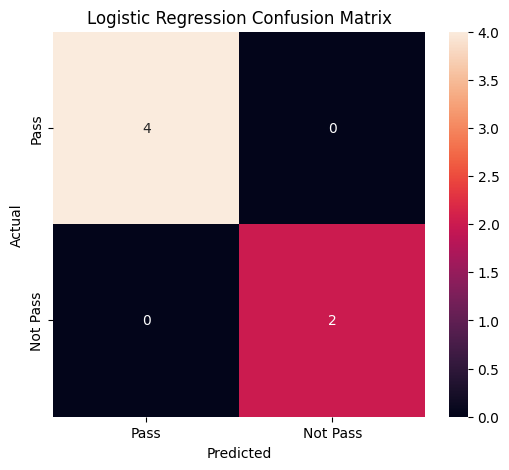

In [24]:
cm = confusion_matrix(
    y_test_c,
    logistic_pred,
    labels=["Pass", "Not Pass"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Pass", "Not Pass"],
    yticklabels=["Pass", "Not Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Decision Tree Classifier

A Decision Tree Classifier is used to predict whether a student is likely to be classified as Pass or Not Pass.

The maximum tree depth is limited to 3 to keep the model simple and reduce the risk of overfitting on the small dataset.

In [25]:
tree_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

tree_classifier.fit(X_train_c, y_train_c)

tree_pred = tree_classifier.predict(X_test_c)

print("Decision Tree Classifier Predictions:")
print(tree_pred)

Decision Tree Classifier Predictions:
['Not Pass' 'Pass' 'Pass' 'Pass' 'Not Pass' 'Pass']


## Decision Tree Classifier Evaluation

The Decision Tree Classifier is evaluated using accuracy, precision, recall, and F1 score.

Using the same metrics as Logistic Regression allows us to compare the two classification models consistently.

In [26]:
tree_accuracy = accuracy_score(
    y_test_c,
    tree_pred
)

tree_precision = precision_score(
    y_test_c,
    tree_pred,
    pos_label="Pass",
    zero_division=0
)

tree_recall = recall_score(
    y_test_c,
    tree_pred,
    pos_label="Pass",
    zero_division=0
)

tree_f1 = f1_score(
    y_test_c,
    tree_pred,
    pos_label="Pass",
    zero_division=0
)

print("Decision Tree Classifier Performance")
print("------------------------------------")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)

Decision Tree Classifier Performance
------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple Decision Trees to make a classification prediction.

Using multiple trees can provide more stable predictions than relying on a single Decision Tree.

In [27]:
random_forest_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_classifier.fit(X_train_c, y_train_c)

rf_pred = random_forest_classifier.predict(X_test_c)

print("Random Forest Classifier Predictions:")
print(rf_pred)

Random Forest Classifier Predictions:
['Not Pass' 'Pass' 'Pass' 'Pass' 'Not Pass' 'Pass']


## Random Forest Classifier Evaluation

The Random Forest Classifier is evaluated using accuracy, precision, recall, and F1 score.

These metrics are the same metrics used for Logistic Regression and Decision Tree Classification, allowing us to compare all classification models consistently.

In [28]:
rf_accuracy = accuracy_score(
    y_test_c,
    rf_pred
)

rf_precision = precision_score(
    y_test_c,
    rf_pred,
    pos_label="Pass",
    zero_division=0
)

rf_recall = recall_score(
    y_test_c,
    rf_pred,
    pos_label="Pass",
    zero_division=0
)

rf_f1 = f1_score(
    y_test_c,
    rf_pred,
    pos_label="Pass",
    zero_division=0
)

print("Random Forest Classifier Performance")
print("-------------------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Classifier Performance
-------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## K-Nearest Neighbors (KNN)

K-Nearest Neighbors classifies a student based on the classes of nearby observations.

Because KNN relies on distances between observations, feature scaling is important. The scaler is fitted only on the training data and then applied to both training and testing data.

In [29]:
scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

print("Scaled training data shape:", X_train_c_scaled.shape)
print("Scaled testing data shape:", X_test_c_scaled.shape)

Scaled training data shape: (24, 7)
Scaled testing data shape: (6, 7)


In [30]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_c_scaled,
    y_train_c
)

knn_pred = knn_model.predict(
    X_test_c_scaled
)

print("KNN Predictions:")
print(knn_pred)

KNN Predictions:
['Not Pass' 'Pass' 'Pass' 'Pass' 'Not Pass' 'Pass']


## K-Nearest Neighbors Evaluation

The KNN model is evaluated using accuracy, precision, recall, and F1 score, consistent with the other classification models.

In [31]:
knn_accuracy = accuracy_score(
    y_test_c,
    knn_pred
)

knn_precision = precision_score(
    y_test_c,
    knn_pred,
    pos_label="Pass",
    zero_division=0
)

knn_recall = recall_score(
    y_test_c,
    knn_pred,
    pos_label="Pass",
    zero_division=0
)

knn_f1 = f1_score(
    y_test_c,
    knn_pred,
    pos_label="Pass",
    zero_division=0
)

print("KNN Performance")
print("----------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Performance
----------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## Classification Model Comparison

The performance of all classification models is compared using accuracy, precision, recall, and F1 score.

Higher values indicate better performance for these metrics. However, because this project uses a small synthetic dataset, the results should be treated as a demonstration of model evaluation rather than as evidence of real-world predictive performance.

In [32]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision,
        knn_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall,
        knn_recall
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1,
        knn_f1
    ]
})

classification_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,KNN,1.0,1.0,1.0,1.0


## Classification Model Performance Visualization

The F1 scores of the classification models are visualized to make their relative performance easier to compare.

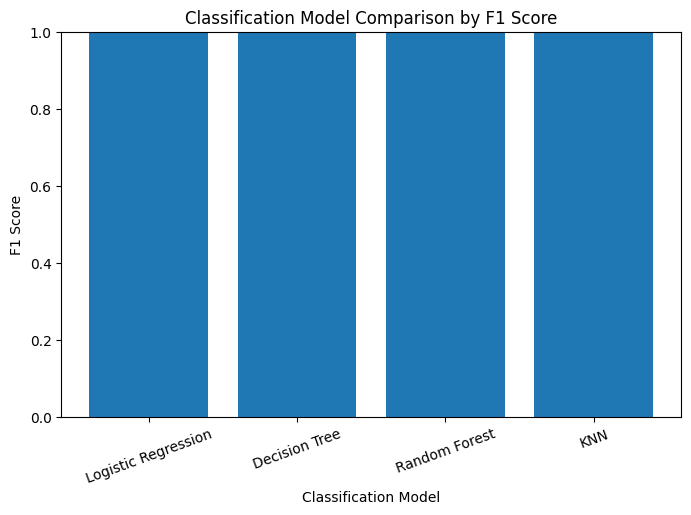

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    classification_comparison["Model"],
    classification_comparison["F1 Score"]
)

plt.xlabel("Classification Model")
plt.ylabel("F1 Score")
plt.title("Classification Model Comparison by F1 Score")

plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

## Best Performing Models

The models are compared using their evaluation metrics. The model with the highest R² score is considered the best regression model for this test set, while the model with the highest F1 score is considered the best classification model.

These results are specific to this dataset and test split.

In [34]:
best_regression = comparison.loc[
    comparison["R2 Score"].idxmax()
]

best_classification = classification_comparison.loc[
    classification_comparison["F1 Score"].idxmax()
]

print("Best Regression Model:")
print(best_regression)

print("\nBest Classification Model:")
print(best_classification)

Best Regression Model:
Model       Linear Regression
MAE                  4.936409
RMSE                  8.30017
R2 Score             -0.91813
Name: 0, dtype: object

Best Classification Model:
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
Name: 0, dtype: object


## Final Results

### Regression Results

Two regression models were trained to predict student exam scores:

- Linear Regression
- Decision Tree Regression

Based on the R² score, Linear Regression was the better-performing regression model on the test set.

The Linear Regression results were:

- MAE: 4.936409
- RMSE: 8.30017
- R² Score: -0.91813

The negative R² score indicates that the Linear Regression model did not explain the variation in the test-set exam scores well. This demonstrates that a model can be successfully trained and evaluated while still having poor predictive performance on a particular test split.

### Classification Results

Four classification models were trained to predict whether a student would be classified as Pass or Not Pass:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors

Based on the F1 score, Logistic Regression was the best-performing classification model on the test set.

The Logistic Regression results were:

- Accuracy: 1.00
- Precision: 1.00
- Recall: 1.00
- F1 Score: 1.00

Although these results are perfect on the test set, the test set contains only six observations. Therefore, the results should not be interpreted as evidence that the model will achieve perfect performance on a larger or real-world dataset.

### Overall Observation

The project demonstrated that different supervised learning algorithms can produce different results on the same dataset. Model evaluation metrics are therefore important for comparing models rather than assuming that a particular algorithm will always perform best.

The dataset used in this project is small and synthetic, so the results are primarily intended to demonstrate the supervised machine learning workflow.

### Future Improvements

Future work could include:

1. Using a larger real-world student dataset.
2. Applying cross-validation to obtain more reliable performance estimates.
3. Performing hyperparameter tuning.
4. Adding more relevant student features.
5. Investigating why the regression models produced low or negative R² scores.
6. Testing the models on a separate dataset to evaluate their generalization ability.